# Person-Specific Sepsis Detection
This notebook evaluates the performance of a person-specific `IsolationForest` model across a cohort of 100 simulated patients. 

### Objectives:
1. **Baseline Training**: Learn the "Normal" physiological baseline for each unique patient.
2. **Randomized Sickness**: Randomly determine if a patient stays healthy or becomes septic.
3. **Modular Pipeline**: Automate the generate-train-predict-evaluate cycle.
4. **Global Metrics**: Calculate Accuracy, Precision, Recall, and F1-score across the entire cohort.
5. **Visual Analysis**: Plot physiological variations with risk alerts over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib
import os
import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration
MODELS_DIR = 'models_cohort'
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

In [2]:
def create_physiological_stream(length_minutes=1440, is_sick=False, baseline_hr=75, baseline_temp=98.2):
    start_time = datetime.datetime.now() - datetime.timedelta(minutes=length_minutes)
    records = []
    
    hr, temp, spo2 = baseline_hr, baseline_temp, 98.0
    
    for m in range(length_minutes):
        current_time = start_time + datetime.timedelta(minutes=m)
        
        if is_sick and m > (length_minutes // 2):
            hr += np.random.normal(0.5, 0.2)
            temp += np.random.normal(0.05, 0.01)
            spo2 -= np.random.normal(0.1, 0.05)
        else:
            hr += np.random.normal(0, 0.5)
            temp += np.random.normal(0, 0.02)
            spo2 += np.random.normal(0, 0.05)
            
        hr = np.clip(hr, 50, 160)
        temp = np.clip(temp, 95.0, 107.0)
        spo2 = np.clip(spo2, 85.0, 100.0)
        
        rr = 15.4 + (hr - baseline_hr) * 0.05 + np.random.normal(0, 0.5)
        rr = np.clip(rr, 10, 40)
        
        movement = np.random.choice([0, 1], p=[0.9, 0.1])
        hrv = np.random.normal(45, 10) if hr < 100 else np.random.normal(25, 5)
        rrv = np.random.normal(3465, 500)
        
        records.append({
            'timestamp': current_time, 
            'hr': round(hr, 2), 'temp': round(temp, 2), 
            'rr': round(rr, 2), 'spo2': round(spo2, 2), 
            'movement': movement, 'hrv': round(hrv, 2), 'rrv': round(rrv, 2)
        })
        
    return pd.DataFrame(records).set_index('timestamp')

def enrich_features(df):
    df = df.copy().ffill().bfill()
    rolling_cols = ['hr', 'rr', 'temp', 'spo2']
    for col in rolling_cols:
        df[f'{col}_rolling_5m'] = df[col].rolling(window=5, min_periods=1).mean()
        df[f'{col}_delta_15m'] = df[f'{col}_rolling_5m'].diff(periods=15).fillna(0)
    return df

In [3]:
def train_model(patient_id, baseline_df):
    train_data = enrich_features(baseline_df)
    model = IsolationForest(contamination=0.05, random_state=42)
    model.fit(train_data)
    path = os.path.join(MODELS_DIR, f'model_{patient_id}.pkl')
    joblib.dump(model, path)
    return model

def predict_windows(patient_id, model, test_df, window_size=15):
    test_data = enrich_features(test_df)
    risk_scores = []
    
    for i in range(0, len(test_data), window_size):
        window = test_data.iloc[i : i + window_size]
        if len(window) < window_size: break
        
        preds = model.predict(window)
        anomaly_ratio = np.sum(preds == -1) / len(preds)
        risk_scores.append(anomaly_ratio)
        
    return risk_scores

In [4]:
num_patients = 5000
cohort_results = []
sample_plots = {} # Store a few examples for plotting

print(f"Starting evaluation for {num_patients} patients...")

for p_idx in range(num_patients):
    p_id = f"patient_{p_idx:03d}"
    
    b_hr = np.random.uniform(60, 90)
    b_temp = np.random.uniform(97.6, 98.6)
    
    # 1. Train on 24hr baseline
    df_base = create_physiological_stream(1440, is_sick=False, baseline_hr=b_hr, baseline_temp=b_temp)
    model = train_model(p_id, df_base)
    
    # 2. Test on 8hr randomized outcome
    should_be_sick = np.random.choice([True, False])
    df_test = create_physiological_stream(480, is_sick=should_be_sick, baseline_hr=b_hr, baseline_temp=b_temp)
    
    # 3. Predict scores
    risk_scores = predict_windows(p_id, model, df_test)
    predicted_sepsis = any(score >= 0.5 for score in risk_scores)
    
    cohort_results.append({
        'patient_id': p_id,
        'actual_sepsis': should_be_sick,
        'predicted_sepsis': predicted_sepsis
    })
    
    # Save some samples for variation plotting (first 2 positive, first 2 negative specimens)
    if len(sample_plots) < 4:
        key = "Sepsis" if should_be_sick else "Healthy"
        if key not in [r['label'] for r in sample_plots.values()]:
             sample_plots[p_id] = {'df': df_test, 'scores': risk_scores, 'label': key}
            
    if (p_idx + 1) % 10 == 0:
        print(f"Processed {p_idx + 1} patients...")

results_df = pd.DataFrame(cohort_results)
print("\nCohort Evaluation Complete.")

Starting evaluation for 5000 patients...
Processed 10 patients...
Processed 20 patients...
Processed 30 patients...
Processed 40 patients...
Processed 50 patients...
Processed 60 patients...
Processed 70 patients...
Processed 80 patients...
Processed 90 patients...
Processed 100 patients...
Processed 110 patients...
Processed 120 patients...
Processed 130 patients...
Processed 140 patients...
Processed 150 patients...
Processed 160 patients...
Processed 170 patients...
Processed 180 patients...
Processed 190 patients...
Processed 200 patients...
Processed 210 patients...
Processed 220 patients...
Processed 230 patients...
Processed 240 patients...
Processed 250 patients...
Processed 260 patients...
Processed 270 patients...
Processed 280 patients...
Processed 290 patients...
Processed 300 patients...
Processed 310 patients...
Processed 320 patients...
Processed 330 patients...
Processed 340 patients...
Processed 350 patients...
Processed 360 patients...
Processed 370 patients...
Proces

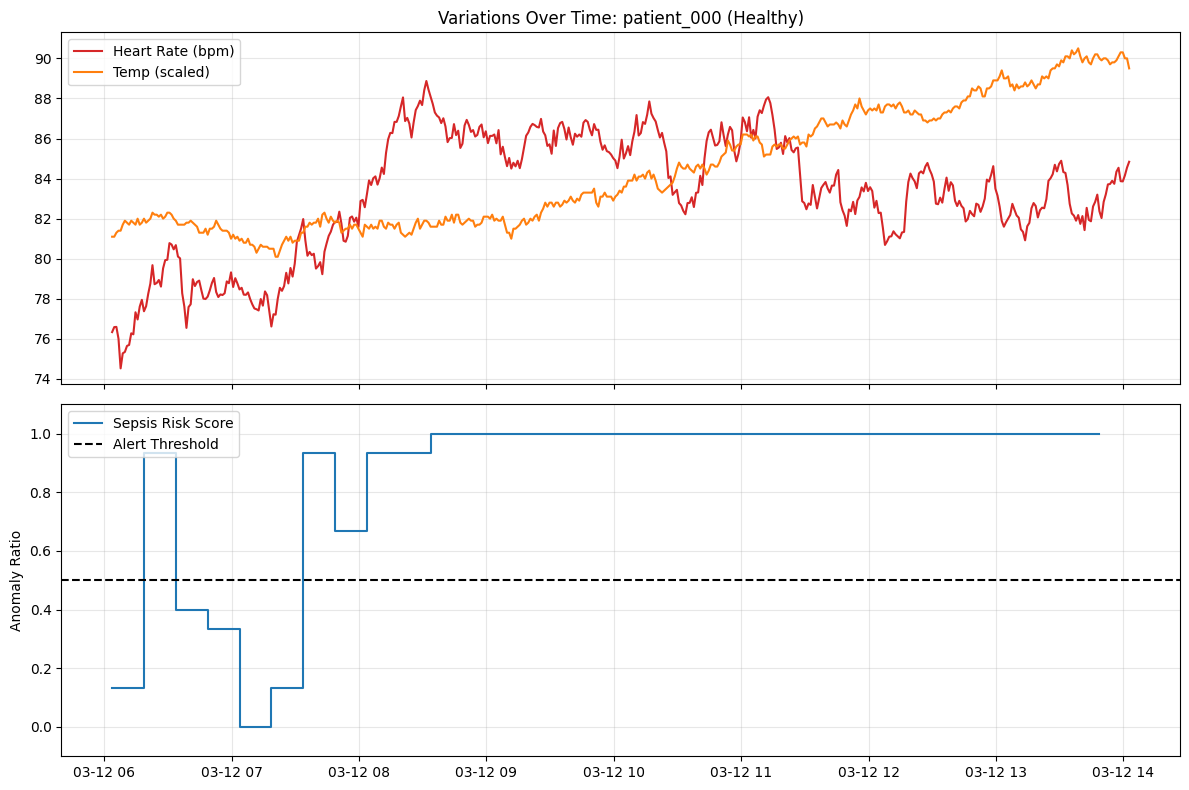

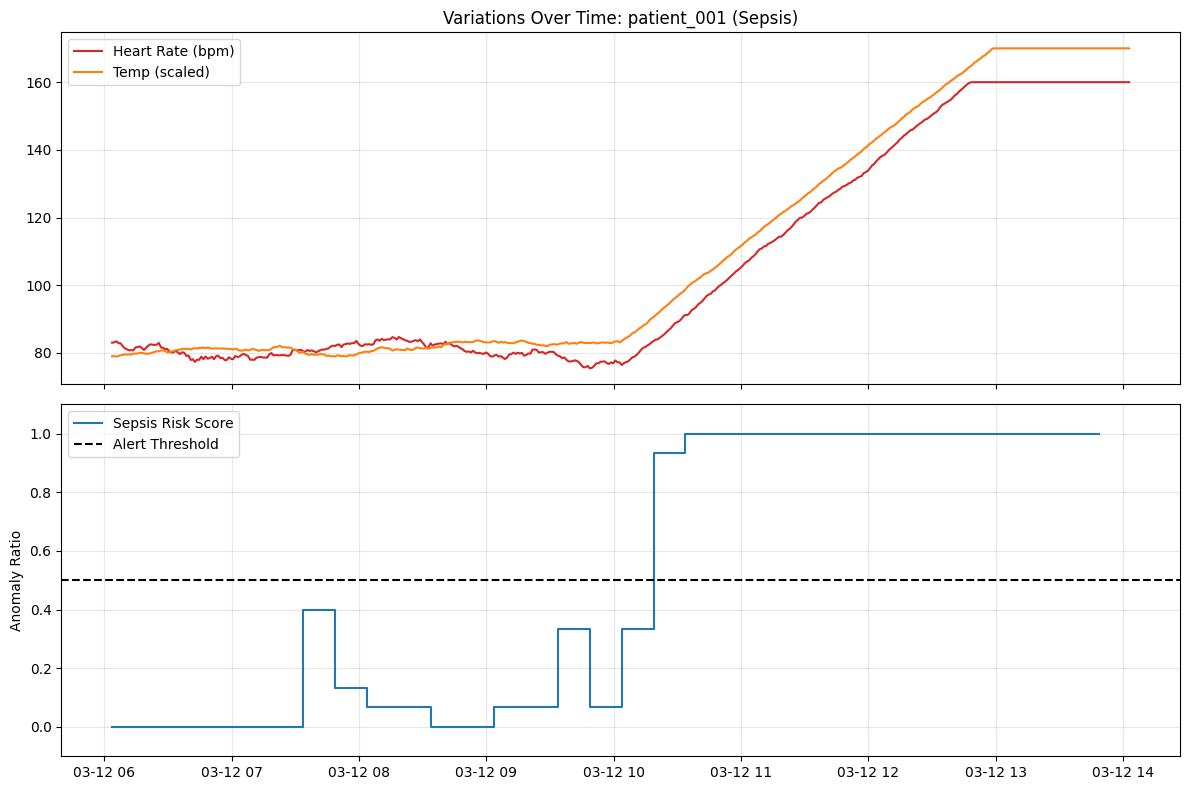

In [5]:
def plot_patient_variation(patient_id, data):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot Vitals
    ax1.plot(data['df'].index, data['df']['hr'], label='Heart Rate (bpm)', color='tab:red')
    ax1.plot(data['df'].index, data['df']['temp']*10-900, label='Temp (scaled)', color='tab:orange')
    ax1.set_title(f"Variations Over Time: {patient_id} ({data['label']})")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Plot Risk Score
    # Interpolate scores to align with timestamps
    score_times = [data['df'].index[i] for i in range(0, len(data['df']), 15)][:len(data['scores'])]
    ax2.step(score_times, data['scores'], where='post', color='tab:blue', label='Sepsis Risk Score')
    ax2.axhline(0.5, color='black', linestyle='--', label='Alert Threshold')
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_ylabel("Anomaly Ratio")
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

for p_id, p_data in sample_plots.items():
    plot_patient_variation(p_id, p_data)

In [6]:
y_true = results_df['actual_sepsis']
y_pred = results_df['predicted_sepsis']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("--- GLOBAL COEFFICIENTS & PERFORMANCE ---")
print(f"Total Patients: {len(results_df)}")
print(f"Accuracy:       {accuracy*100:.2f}%")
print(f"Precision:      {precision*100:.2f}%")
print(f"Recall:         {recall*100:.2f}%")
print(f"F1 Score:       {f1:.3f}")

print("\nDetailed Outcome Distribution:")
print(results_df[['actual_sepsis', 'predicted_sepsis']].value_counts())

--- GLOBAL COEFFICIENTS & PERFORMANCE ---
Total Patients: 5000
Accuracy:       58.18%
Precision:      54.91%
Recall:         100.00%
F1 Score:       0.709

Detailed Outcome Distribution:
actual_sepsis  predicted_sepsis
True           True                2546
False          True                2091
               False                363
Name: count, dtype: int64
